In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/everest/exposures-everest.fits', ext='EXPOSURES'))
print(len(cat), len(np.unique(cat['EXPID'])))

tileid_list = [80613]

mask = np.in1d(cat['TILEID'], tileid_list)
cat = cat[mask]
print(len(cat), len(np.unique(cat['EXPID'])))
cat.sort('EXPID')

cat[:1]

3912 3912
30 30


NIGHT,EXPID,TILEID,TILERA,TILEDEC,MJD,SURVEY,FAPRGRM,FAFLAVOR,EXPTIME,EFFTIME_SPEC,GOALTIME,GOALTYPE,MINTFRAC,AIRMASS,EBV,SEEING_ETC,EFFTIME_ETC,TSNR2_ELG,TSNR2_QSO,TSNR2_LRG,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBDARK,TSNR2_GPBBRIGHT,TSNR2_GPBBACKUP,ELG_EFFTIME_DARK,BGS_EFFTIME_BRIGHT,LYA_EFFTIME_DARK,GPB_EFFTIME_DARK,GPB_EFFTIME_BRIGHT,GPB_EFFTIME_BACKUP,TRANSPARENCY_GFA,SEEING_GFA,FIBER_FRACFLUX_GFA,FIBER_FRACFLUX_ELG_GFA,FIBER_FRACFLUX_BGS_GFA,FIBERFAC_GFA,FIBERFAC_ELG_GFA,FIBERFAC_BGS_GFA,AIRMASS_GFA,SKY_MAG_AB_GFA,SKY_MAG_G_SPEC,SKY_MAG_R_SPEC,SKY_MAG_Z_SPEC,EFFTIME_GFA,EFFTIME_DARK_GFA,EFFTIME_BRIGHT_GFA,EFFTIME_BACKUP_GFA
int32,int32,int32,float64,float64,float64,str7,str16,str19,float64,float32,float64,str7,float64,float32,float64,float64,float32,float32,float32,float32,float64,float32,float32,float32,float32,float32,float32,float64,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
20201218,68657,80613,106.74,56.1,59202.25187735,sv1,bgsmws,sv1bgsmws,300.08599853515625,270.37234,0.0,bright,0.9,1.236016,0.05588603392243385,0.0,0.0,33.34936,8.186114,21.847433,18.166124705737456,1931.2311,2851.0486,521.33795,3418.9175,286.80453,270.37234,207.81607098549128,246.80737,273.82373,250.57013,0.9915462700098784,0.8323025641388946,0.7414856403546808,0.5167326565985351,0.2320292707103295,1.2126583295107185,1.1621211419552857,1.1360109853642024,1.2359980646718274,20.901247658537635,22.160002419021197,21.353755768017038,19.713345098761724,244.6203227675448,240.60869493483875,244.6203227675448,307.8473475450303


In [4]:
mask = cat['BGS_EFFTIME_BRIGHT']/cat['EXPTIME'] > 0.2
cat = cat[mask]
print(len(cat))

14


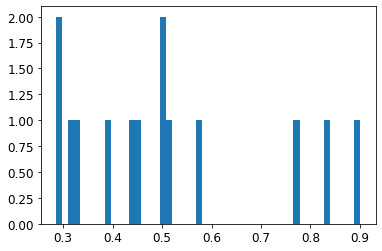

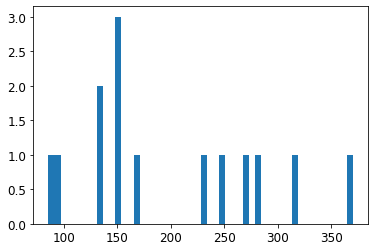

In [5]:
plt.hist(cat['BGS_EFFTIME_BRIGHT']/cat['EXPTIME'], 50)
plt.show()

plt.hist(cat['BGS_EFFTIME_BRIGHT'], 50)
plt.show()

In [6]:
for tileid in np.unique(cat['TILEID']):
    mask = cat['TILEID']==tileid
    print(tileid, np.sum(cat['BGS_EFFTIME_BRIGHT'][mask]), np.sum(mask), cat['FAFLAVOR'][mask][0])

80613 2795.7424 14 sv1bgsmws


In [7]:
for tileid in np.unique(cat['TILEID']):
    mask = cat['TILEID']==tileid
    print(tileid, np.sum(cat['BGS_EFFTIME_BRIGHT'][mask]), np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])/720.)

80613 2795.7424 3.882975599500868


In [8]:
print('TILEID n_exp tot_depth n_sub_min n_sub_max  n_sub')
for tileid in np.unique(cat['TILEID']):
    if tileid==80613:
        nom_depth = 720.
    else:
        nom_depth = 4000.
    mask = cat['TILEID']==tileid
    tot_depth = np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])
    n_sub_min = tot_depth/nom_depth
    if n_sub_min < 2:
        margin = 0.15
    else:
        margin = 0.1
    n_sub_max = tot_depth/(nom_depth*(1-margin))
    n_sub = int(np.floor(n_sub_max))
    print(tileid, '{:3} {:12.2f} {:9.2f} {:9.2f} {:6}'.format(np.sum(mask), tot_depth, n_sub_min, n_sub_max, n_sub))

TILEID n_exp tot_depth n_sub_min n_sub_max  n_sub
80613  14      2795.74      3.88      4.31      4


----

In [9]:
np.random.seed(511)

subsamp_dict = {}

# tileid = 80607
for tileid in np.unique(cat['TILEID']):
    
    print()
    
    if tileid==80613:
        nom_depth = 720.
        depth_col = 'BGS_EFFTIME_BRIGHT'
    else:
        nom_depth = 4000.
        depth_col = 'EFFTIME_SPEC'
    mask = cat['TILEID']==tileid

    n_exp = np.sum(mask)

    tot_depth = np.sum(cat[depth_col][mask])
    n_sub_min = tot_depth/nom_depth
    if n_sub_min < 2:
        margin = 0.15
    else:
        margin = 0.1
    n_sub_max = tot_depth/(nom_depth*(1-margin))
    n_sub = int(np.floor(n_sub_max))
    print(tileid, '{:3} {:9.2f} {:6.2f} {:6.2f} {:3}'.format(np.sum(mask), tot_depth, n_sub_min, n_sub_max, n_sub))

    mask = cat['TILEID']==tileid
    expid_list = np.array(cat['EXPID'][mask])
    subsets = []

    total_iteration = 0
    while True:
        total_iteration += 1
        success = False
        iteration = 0
        while success==False:
            iteration += 1
            subset = []
            subset_depth = []
            while True:
                mask = ~np.in1d(expid_list, subset)
                expid = np.random.choice(expid_list[mask])
                subset.append(expid)
                subset_depth.append(cat[depth_col][cat['EXPID']==expid][0])

                if total_iteration<200:
                    margin = 0.05
                elif ((total_iteration>200) & (total_iteration<400)):
                    margin = 0.1
                elif (total_iteration>400):
                    margin = 0.15
                if (np.sum(subset_depth)>(1-margin)*nom_depth) and (np.sum(subset_depth)<(1+margin)*nom_depth):
    #             if (np.sum(subset_depth)>0.8*nom_depth) and (np.sum(subset_depth)<1.2*nom_depth):
                    success = True
                    # print(np.sum(subset_depth))
                    break
                if len(subset)==len(expid_list):
                    break
            if iteration>(np.minimum(100, np.math.factorial(n_exp))):
                # reset
                mask = cat['TILEID']==tileid
                expid_list = np.array(cat['EXPID'][mask])
                subsets = []
                break
        if success:
            subsets.append(subset)
            mask = ~np.in1d(expid_list, np.concatenate(subsets))
            expid_list = expid_list[mask]
        if len(subsets)==n_sub:
            break
    
    print('tile', tileid, subsets)
    subsamp_dict[str(tileid)] = subsets
    for subset in subsets:
        mask = np.in1d(cat['EXPID'], subset)
        print(np.sum(mask), np.sum(cat[depth_col][mask]))


80613  14   2795.74   3.88   4.31   4
tile 80613 [[69226, 68658, 69230, 69228], [81833, 81834], [81835, 69227, 68657], [69229, 81832, 69225, 68659, 81831]]
4 690.70325
2 686.6193
3 723.8264
5 694.5935


In [10]:
subsamp_dict

{'80613': [[69226, 68658, 69230, 69228],
  [81833, 81834],
  [81835, 69227, 68657],
  [69229, 81832, 69225, 68659, 81831]]}

In [11]:
# Print summary
for tileid_str in subsamp_dict.keys():
    tileid = int(tileid_str)
    mask = cat['TILEID']==tileid
    n_exp = np.sum(mask)
    tot_depth = np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])
    print('Tile {}:'.format(tileid))
    print('all:       n_exp={:2}  depth={:5.0f}s'.format(n_exp, tot_depth))
    subsets = subsamp_dict[tileid_str]
    for index, subset in enumerate(subsets):
        mask = np.in1d(cat['EXPID'], subset)
        subset_depth = np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])
        print('subset {}:  n_exp={:2}  depth={:5.0f}s'.format(index+1, len(subset), subset_depth))
    mask = (cat['TILEID']==tileid) & (~np.in1d(cat['EXPID'], np.concatenate(subsets)))
    unused_depth = np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])
    print('unused:    n_exp={:2}  depth={:5.0f}s'.format(np.sum(mask), unused_depth))
    print()

Tile 80613:
all:       n_exp=14  depth= 2796s
subset 1:  n_exp= 4  depth=  691s
subset 2:  n_exp= 2  depth=  687s
subset 3:  n_exp= 3  depth=  724s
subset 4:  n_exp= 5  depth=  695s
unused:    n_exp= 0  depth=    0s

